# Driving School Installs Prediction — ARIMA Family

Unified notebook combining **ARIMA**, **SARIMA**, and **SARIMAX** models.
Shared preprocessing runs once; each model's parameter search, fitting,
rolling evaluation, and saving are kept in separate sections.

## Imports

In [44]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from utils import check_stationarity

warnings.filterwarnings("ignore")

## Hyperparameters & Config

In [45]:
DATA_CSV_FILE   = "../../../data/ds_data_clean.csv"
TARGET_COL      = "Daily User Installs"
EXOG_COLS       = [
    "Daily Device Uninstalls",
    # "User to Device Ratio",
    "Daily User Uninstalls",
    "Active Device Installs",
    "Daily Average Rating",
    "Daily Crashes",
    "Daily ANRs",
    "Is Weekend",
]
TRAIN_RATIO     = 0.8
SEASONAL_PERIOD = 7   # Weekly seasonality
ROLL_PERIOD     = 7   # Rolling forecast window (days)

## Loading Data

In [46]:
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df["Is Weekend"] = (df["Date"].dt.dayofweek >= 5).astype(int)  # 5=Sat, 6=Sun
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)
df.head()

,Package Name,Daily Device Installs,Daily Device Uninstalls,Daily Device Upgrades,Total User Installs,Daily User Installs,Daily User Uninstalls,Active Device Installs,Install events,Update events,Uninstall events,Daily Average Rating,Total Average Rating,Daily Crashes,Daily ANRs,Is Weekend
Date,,,,,,,,,,,,,,,,
2019-09-02,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,2,0,0,0,2,1,1,2,0,1,0.0,0.0,0,0,0
2019-09-03,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,1,0,0,0,1,0,3,2,1,0,0.0,0.0,0,0,0
2019-09-04,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,2,0,0,0,2,0,6,2,0,0,0.0,0.0,0,0,0
2019-09-05,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,3,0,0,0,3,2,6,3,0,2,0.0,0.0,0,0,0
2019-09-06,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,6,0,0,0,6,2,9,6,0,2,0.0,0.0,0,0,0


## Stationarity Check

In [47]:
check_stationarity(df[TARGET_COL], title=TARGET_COL)

--- Stationarity Tests for Daily User Installs ---
ADF Statistic: -3.9122
ADF p-value: 0.0019
ADF Critical Values:
   1%: -3.4332
   5%: -2.8628
   10%: -2.5674
KPSS Statistic: 0.5268
KPSS p-value: 0.0356
KPSS Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: The series is likely non-stationary.


## Preprocessing and Temporal Split

In [48]:
train_size = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:train_size]
test_df  = df.iloc[train_size:]

# Univariate series (ARIMA / SARIMA)
train = train_df[TARGET_COL]
test  = test_df[TARGET_COL]

# Multivariate split (SARIMAX)
y_train = train_df[TARGET_COL]
y_test  = test_df[TARGET_COL]
X_train = train_df[EXOG_COLS]
X_test  = test_df[EXOG_COLS]

print(f"Train: {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train)} days)")
print(f"Test:  {test_df.index[0].date()} → {test_df.index[-1].date()}  ({len(test)} days)")

Train: 2019-09-02 → 2024-09-24  (1850 days)
Test:  2024-09-25 → 2025-12-31  (463 days)


## Rolling Forecast Helper

Walk-forward evaluation shared by all three models. At each chunk the model
is refit on all history seen so far, forecasts `ROLL_PERIOD` steps ahead,
then the true values are revealed before the next chunk.

In [49]:
def rolling_forecast(fit_fn, endog_train, endog_test,
                     exog_train=None, exog_test=None,
                     roll_period=ROLL_PERIOD):
    """
    Walk-forward (rolling) validation.

    Parameters
    ----------
    fit_fn      : callable(history_y, history_X, steps, chunk_X) -> array
                  Fits the model on current history and returns forecasts.
    endog_train : pd.Series  — training target
    endog_test  : pd.Series  — test target
    exog_train  : pd.DataFrame | None — training exog (SARIMAX only)
    exog_test   : pd.DataFrame | None — test exog (SARIMAX only)
    roll_period : int — chunk size (days per re-fit)

    Returns
    -------
    pd.Series of rolling predictions aligned to endog_test.index
    """
    history_y = list(endog_train.copy())
    history_X = exog_train.copy() if exog_train is not None else None
    preds = []

    for start in range(0, len(endog_test), roll_period):
        chunk_y = endog_test.iloc[start : start + roll_period]
        chunk_X = exog_test.iloc[start : start + roll_period] if exog_test is not None else None

        yhats = fit_fn(history_y, history_X, len(chunk_y), chunk_X)
        preds.extend(yhats)

        history_y.extend(chunk_y.tolist())
        if history_X is not None:
            history_X = pd.concat([history_X, chunk_X])

    return pd.Series(preds, index=endog_test.index)

def rolling_forecast_no_refit(initial_res, endog_test, exog_test=None, roll_period=ROLL_PERIOD):
    """
    Walk-forward (rolling) validation using statsmodels extend() method.
    This updates the model state with new observations WITHOUT refitting parameters.
    """
    preds = []
    current_res = initial_res

    for start in range(0, len(endog_test), roll_period):
        chunk_y = endog_test.iloc[start : start + roll_period]
        chunk_X = exog_test.iloc[start : start + roll_period] if exog_test is not None else None
        steps = len(chunk_y)

        # 1. Forecast next window
        yhats = current_res.forecast(steps=steps, exog=chunk_X)
        preds.extend(yhats)

        # 2. Update model state with the actual values revealed
        current_res = current_res.extend(chunk_y, exog=chunk_X)

    return pd.Series(preds, index=endog_test.index)

def evaluate_and_plot(name, actual, preds, color, roll_period=ROLL_PERIOD):
    """Print RMSE/MAE and plot actual vs rolling forecast."""
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)

    print("-" * 35)
    print(f"{name} ROLLING FORECAST RESULTS")
    print(f"  (re-fit every {roll_period} days)")
    print("-" * 35)
    print(f"RMSE: {rmse:.2f} installs")
    print(f"MAE:  {mae:.2f} installs")
    print("-" * 35)

    days = range(len(actual))
    
    plt.figure(figsize=(14, 5))
    plt.plot(days, actual, label="Actual", color="royalblue", alpha=0.8)
    plt.plot(days, preds,  label=f"Rolling Forecast ({roll_period}d)",
             color=color, linestyle="--")
    plt.title(f"Daily Install Prediction — {name} (Rolling {roll_period}-Day)")
    plt.xlabel("Days (Test Period)")
    plt.ylabel("Daily User Installs")
    plt.legend()
    plt.tight_layout()
    
    filename = f"{name.replace(' ', '_').lower()}_forecast_{roll_period}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

    return rmse, mae


def plot_residuals(name, actual, preds,roll_period=ROLL_PERIOD):
    """Histogram of forecast residuals."""
    residuals = actual - preds
    plt.figure(figsize=(10, 5))
    plt.hist(residuals, bins=50, color="lightcoral", edgecolor="black")
    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"{name} Rolling Forecast Residuals (Actual - Predicted)")

    filename = f"{name.replace(' ', '_').lower()}_residuals_{roll_period}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()


def save_model(model_fit, model_path, meta_path, meta):
    """Save fitted statsmodels result and metadata JSON."""
    model_fit.save(model_path)
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"Model saved    → {model_path}")
    print(f"Metadata saved → {meta_path}")


def load_model(model_path, meta_path=None):
    """Load statsmodels result and metadata JSON."""
    if "sarima" in model_path.lower():
        m = SARIMAXResults.load(model_path)
    else:
        m = ARIMAResults.load(model_path)
    
    meta = None
    if meta_path and os.path.exists(meta_path):
        with open(meta_path, "r") as f:
            meta = json.load(f)
    print(f"Model loaded   ← {model_path}")
    return m, meta

---
# Model 1: ARIMA
Univariate, non-seasonal baseline.

## ARIMA — Parameter Search

In [50]:
ARIMA_MODEL_PATH = "arima_model.pkl"
ARIMA_META_PATH  = "arima_model_meta.json"

if os.path.exists(ARIMA_MODEL_PATH):
    arima_fit, meta = load_model(ARIMA_MODEL_PATH, ARIMA_META_PATH)
    ap, ad, aq = arima_fit.specification['order']
else:
    print("Training new ARIMA model...")
    arima_auto = auto_arima(
        train,
        seasonal=False,
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
    )
    ap, ad, aq = arima_auto.order
    arima_model = ARIMA(train, order=(ap, ad, aq))
    arima_fit   = arima_model.fit()

print(arima_fit.summary())

Model loaded   ← arima_model.pkl
                                SARIMAX Results                                
Dep. Variable:     Daily User Installs   No. Observations:                 1850
Model:                  ARIMA(4, 1, 1)   Log Likelihood              -20729.405
Date:                 Wed, 15 Apr 2026   AIC                          41470.811
Time:                         14:51:08   BIC                          41503.945
Sample:                     09-02-2019   HQIC                         41483.025
                          - 09-24-2024                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8305      0.010    -82.689      0.000      -0.850      -0.811
ar.L2         -0.0746      0.010     -7.631      0.000      -0.094      -0.055
ar.L3      

## ARIMA — Rolling Forecast & Evaluation

-----------------------------------
ARIMA ROLLING FORECAST RESULTS
  (re-fit every 7 days)
-----------------------------------
RMSE: 8840.68 installs
MAE:  4735.37 installs
-----------------------------------


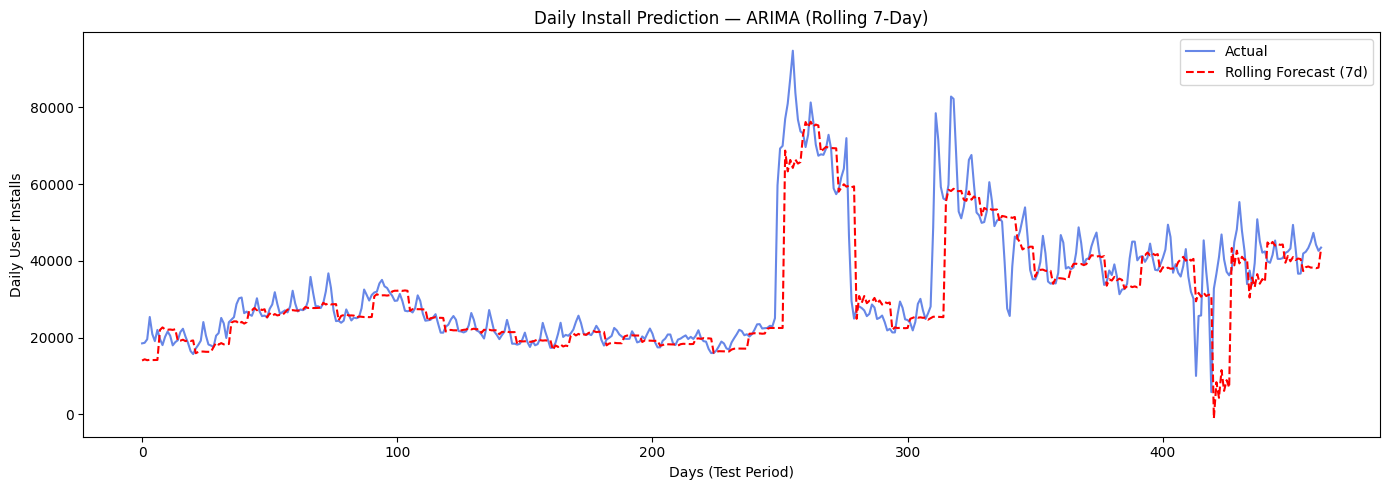

In [51]:
arima_preds          = rolling_forecast_no_refit(arima_fit, test)
arima_rmse, arima_mae = evaluate_and_plot("ARIMA", test, arima_preds, color="red")

## ARIMA — Residual Analysis

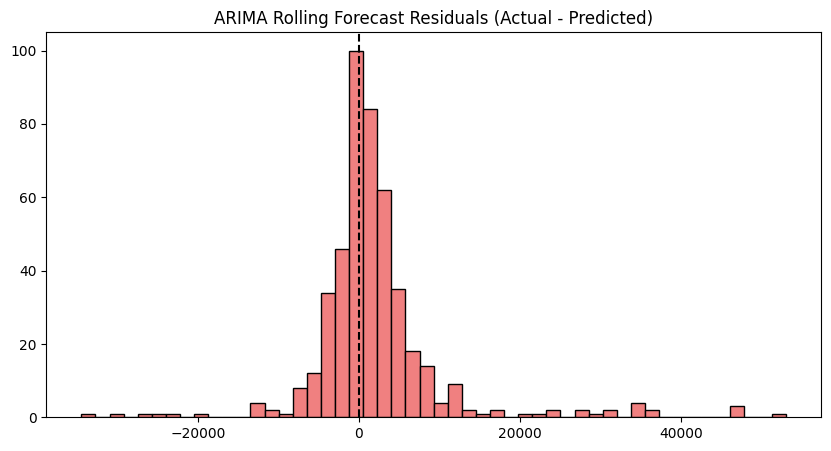

In [52]:
plot_residuals("ARIMA", test, arima_preds)

## ARIMA — Save Model

In [53]:
save_model(
    arima_fit,
    "arima_model.pkl",
    "arima_model_meta.json",
    meta={
        "model":            "ARIMA",
        "order":            [ap, ad, aq],
        "target_col":       TARGET_COL,
        "train_ratio":      TRAIN_RATIO,
        "forecast_type":    "rolling_nstep",
        "roll_period_days": ROLL_PERIOD,
        "train_start":      str(train_df.index[0].date()),
        "train_end":        str(train_df.index[-1].date()),
        "test_start":       str(test_df.index[0].date()),
        "test_end":         str(test_df.index[-1].date()),
        "rmse":             round(arima_rmse, 4),
        "mae":              round(arima_mae,  4),
    }
)

Model saved    → arima_model.pkl
Metadata saved → arima_model_meta.json


---
# Model 2: SARIMA
Univariate with weekly seasonality.

## SARIMA — Parameter Search

In [54]:
SARIMA_MODEL_PATH = "sarima_model.pkl"
SARIMA_META_PATH  = "sarima_model_meta.json"

if os.path.exists(SARIMA_MODEL_PATH):
    sarima_fit, meta = load_model(SARIMA_MODEL_PATH, SARIMA_META_PATH)
    sp, sd, sq = sarima_fit.specification['order']
    sP, sD, sQ, ss = sarima_fit.specification['seasonal_order']
else:
    print("Training new SARIMA model...")
    sarima_auto = auto_arima(
        train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
    )
    sp, sd, sq = sarima_auto.order
    sP, sD, sQ, ss = sarima_auto.seasonal_order

    sarima_model = SARIMAX(
        train,
        order=(sp, sd, sq),
        seasonal_order=(sP, sD, sQ, ss),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

Model loaded   ← sarima_model.pkl
                                       SARIMAX Results                                        
Dep. Variable:                    Daily User Installs   No. Observations:                 1850
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 7)   Log Likelihood              -20564.243
Date:                                Wed, 15 Apr 2026   AIC                          41140.487
Time:                                        14:51:09   BIC                          41173.569
Sample:                                    09-02-2019   HQIC                         41152.688
                                         - 09-24-2024                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9667      0.002    391.454     

## SARIMA — Rolling Forecast & Evaluation

-----------------------------------
SARIMA ROLLING FORECAST RESULTS
  (re-fit every 7 days)
-----------------------------------
RMSE: 7992.15 installs
MAE:  4315.43 installs
-----------------------------------


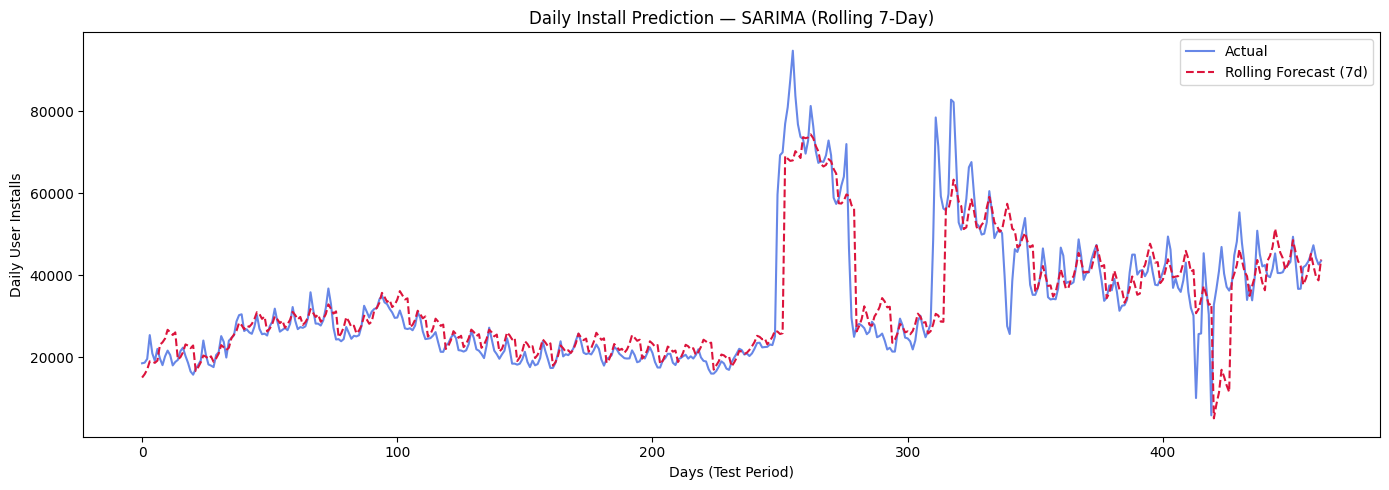

In [55]:
sarima_preds            = rolling_forecast_no_refit(sarima_fit, test)
sarima_rmse, sarima_mae = evaluate_and_plot("SARIMA", test, sarima_preds, color="crimson")

## SARIMA — Residual Analysis

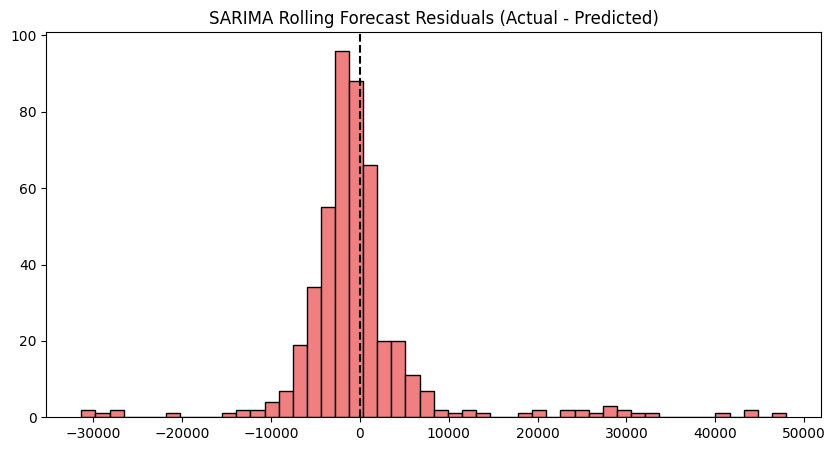

In [56]:
plot_residuals("SARIMA", test, sarima_preds)

## SARIMA — Save Model

In [57]:
save_model(
    sarima_fit,
    "sarima_model.pkl",
    "sarima_model_meta.json",
    meta={
        "model":            "SARIMA",
        "order":            [sp, sd, sq],
        "seasonal_order":   [sP, sD, sQ, ss],
        "seasonal_period":  SEASONAL_PERIOD,
        "target_col":       TARGET_COL,
        "train_ratio":      TRAIN_RATIO,
        "forecast_type":    "rolling_nstep",
        "roll_period_days": ROLL_PERIOD,
        "train_start":      str(train_df.index[0].date()),
        "train_end":        str(train_df.index[-1].date()),
        "test_start":       str(test_df.index[0].date()),
        "test_end":         str(test_df.index[-1].date()),
        "rmse":             round(sarima_rmse, 4),
        "mae":              round(sarima_mae,  4),
    }
)

Model saved    → sarima_model.pkl
Metadata saved → sarima_model_meta.json


---
# Model 3: SARIMAX
Multivariate — seasonal ARIMA with exogenous features.

## SARIMAX — Parameter Search

In [58]:
SARIMAX_MODEL_PATH = "sarimax_model.pkl"
SARIMAX_META_PATH  = "sarimax_model_meta.json"

if os.path.exists(SARIMAX_MODEL_PATH):
    sarimax_fit, meta = load_model(SARIMAX_MODEL_PATH, SARIMAX_META_PATH)
    xp, xd, xq = sarimax_fit.specification['order']
    xP, xD, xQ, xs = sarimax_fit.specification['seasonal_order']
else:
    print("Training new SARIMAX model...")
    sarimax_auto = auto_arima(
        y_train,
        X=X_train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
    )
    xp, xd, xq = sarimax_auto.order
    xP, xD, xQ, xs = sarimax_auto.seasonal_order

    sarimax_model = SARIMAX(
        y_train,
        exog=X_train,
        order=(xp, xd, xq),
        seasonal_order=(xP, xD, xQ, xs),
    )
    sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

Model loaded   ← sarimax_model.pkl
                                       SARIMAX Results                                        
Dep. Variable:                    Daily User Installs   No. Observations:                 1850
Model:             SARIMAX(2, 0, 3)x(2, 0, [1, 2], 7)   Log Likelihood              -19459.261
Date:                                Wed, 15 Apr 2026   AIC                          38952.523
Time:                                        14:51:09   BIC                          39046.413
Sample:                                    09-02-2019   HQIC                         38987.134
                                         - 09-24-2024                                         
Covariance Type:                                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Daily Device Uninstal

## SARIMAX — Rolling Forecast & Evaluation

-----------------------------------
SARIMAX ROLLING FORECAST RESULTS
  (re-fit every 7 days)
-----------------------------------
RMSE: 6660.13 installs
MAE:  3361.94 installs
-----------------------------------


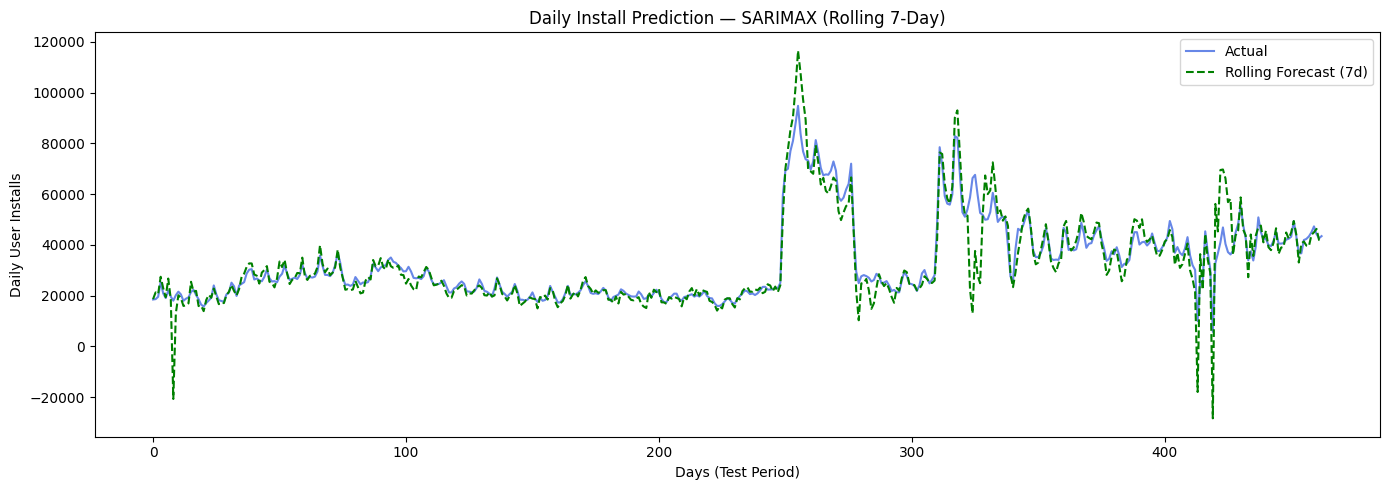

In [59]:
sarimax_preds              = rolling_forecast_no_refit(sarimax_fit, y_test,
                                              exog_test=X_test)
sarimax_rmse, sarimax_mae = evaluate_and_plot("SARIMAX", y_test, sarimax_preds, color="green")

## SARIMAX — Residual Analysis

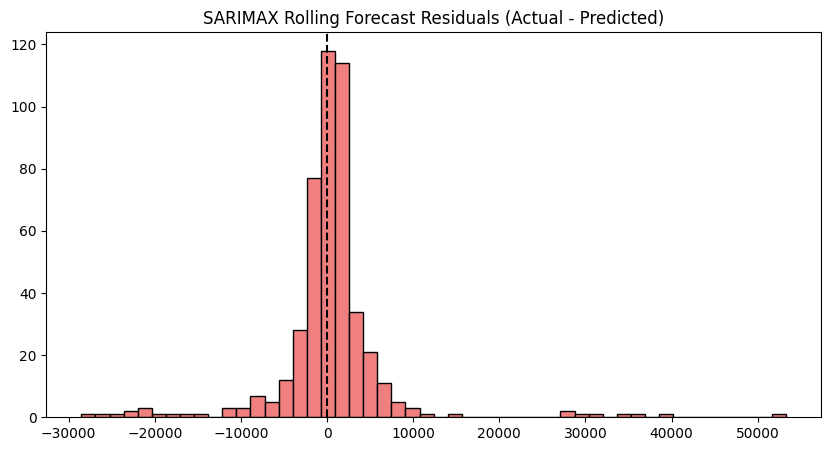

In [60]:
plot_residuals("SARIMAX", y_test, sarimax_preds)

## SARIMAX — Save Model

In [61]:
save_model(
    sarimax_fit,
    "sarimax_model.pkl",
    "sarimax_model_meta.json",
    meta={
        "model":            "SARIMAX",
        "order": [xp, xd, xq],
        "seasonal_order": [xP, xD, xQ, xs],
        "seasonal_period":  SEASONAL_PERIOD,
        "target_col":       TARGET_COL,
        "exog_cols":        EXOG_COLS,
        "train_ratio":      TRAIN_RATIO,
        "forecast_type":    "rolling_nstep",
        "roll_period_days": ROLL_PERIOD,
        "train_start":      str(train_df.index[0].date()),
        "train_end":        str(train_df.index[-1].date()),
        "test_start":       str(test_df.index[0].date()),
        "test_end":         str(test_df.index[-1].date()),
        "rmse":             round(sarimax_rmse, 4),
        "mae":              round(sarimax_mae,  4),
    }
)

Model saved    → sarimax_model.pkl
Metadata saved → sarimax_model_meta.json


---
# Model Comparison

      MODEL COMPARISON SUMMARY
           RMSE     MAE
Model                  
ARIMA   8840.68 4735.37
SARIMA  7992.15 4315.43
SARIMAX 6660.13 3361.94
Best RMSE → SARIMAX
Best MAE  → SARIMAX


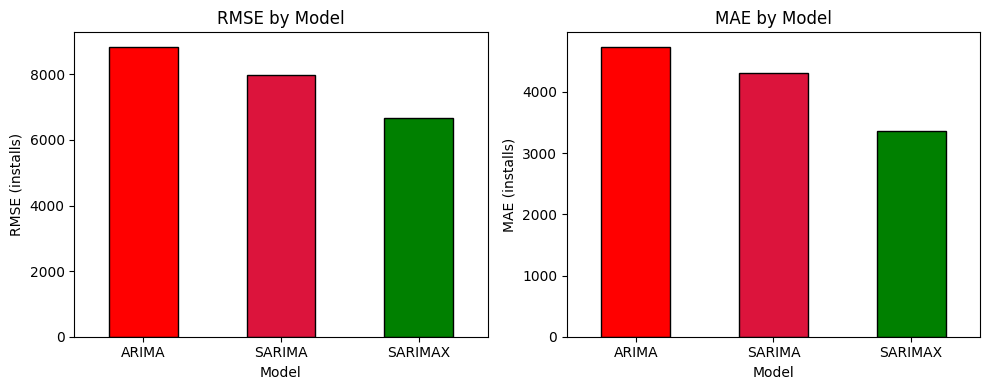

In [62]:
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "SARIMAX"],
    "RMSE":  [arima_rmse,   sarima_rmse,   sarimax_rmse],
    "MAE":   [arima_mae,    sarima_mae,    sarimax_mae],
}).set_index("Model")

print("=" * 35)
print("      MODEL COMPARISON SUMMARY")
print("=" * 35)
print(results.to_string(float_format="{:.2f}".format))
print("=" * 35)
print(f"Best RMSE → {results["RMSE"].idxmin()}")
print(f"Best MAE  → {results["MAE"].idxmin()}")

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["RMSE"].plot(kind="bar", ax=axes[0], color=["red","crimson","green"], edgecolor="black")
axes[0].set_title("RMSE by Model")
axes[0].set_ylabel("RMSE (installs)")
axes[0].tick_params(axis="x", rotation=0)

results["MAE"].plot(kind="bar", ax=axes[1], color=["red","crimson","green"], edgecolor="black")
axes[1].set_title("MAE by Model")
axes[1].set_ylabel("MAE (installs)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()

filename = f"ModelComparison_{ROLL_PERIOD}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

plt.show()